# **ИМПОРТ БИБЛИОТЕК**

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2D, Conv2DTranspose, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam

%matplotlib inline

# **ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ**

In [ ]:

# Загрузка оригинального датасета MNIST
(X_train_org, _), (X_test_org, _) = mnist.load_data()

# Нормировка данных в диапазон [0, 1]
X_train_org = X_train_org.astype('float32') / 255.
X_test_org = X_test_org.astype('float32') / 255.

# Изменение формы под сверточные слои (добавление канала)
X_train_org = np.expand_dims(X_train_org, axis=-1)
X_test_org = np.expand_dims(X_test_org, axis=-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **ФУНКЦИЯ НАЛОЖЕНИЯ**

In [ ]:

def add_black_squares(images, square_size=8):
    # Копируем массив, чтобы не повредить оригиналы
    corrupted_images = np.copy(images)
    num_images, height, width, channels = images.shape

    for i in range(num_images):
        # Случайная координата верхнего левого угла квадрата
        # так, чтобы квадрат не выходил за границы изображения 28x28
        y = np.random.randint(0, height - square_size + 1)
        x = np.random.randint(0, width - square_size + 1)

        # Зануляем (делаем черной) область 8x8
        corrupted_images[i, y:y+square_size, x:x+square_size, 0] = 0.0

    return corrupted_images

# Создаем зашумленные выборки
np.random.seed(42) # Фиксация генератора для воспроизводимости
X_train_masked = add_black_squares(X_train_org)
X_test_masked = add_black_squares(X_test_org)

print(f"Формат оригинальных данных: {X_train_org.shape}")
print(f"Формат данных с квадратами: {X_train_masked.shape}")

Формат оригинальных данных: (60000, 28, 28, 1)
Формат данных с квадратами: (60000, 28, 28, 1)


# **АРХИТЕКТУРА СВЕРТОЧНОГО АВТОКОДИРОВЩИКА**

In [ ]:

# Входной слой для зашумленной картинки 28x28x1
inputs = Input(shape=(28, 28, 1), name="Input_Masked")

# Энкодер (Извлечение признаков и сжатие)
x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), padding='same', strides=2, activation='relu')(x) # Глубокие фичи, размер 14x14
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), padding='same', strides=2, activation='relu')(x) # Размер 7x7
x = BatchNormalization()(x)

# Декодер (Восстановление отсутствующих областей)
x = Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(x) # Возврат к 14x14
x = BatchNormalization()(x)
x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x) # Возврат к 28x28
x = BatchNormalization()(x)

# Финальный слой восстановления интенсивности пикселей [0, 1]
outputs = Conv2D(1, (3, 3), padding='same', activation='sigmoid', name="Output_Clean")(x)

# Сборка и компиляция модели
autoencoder = Model(inputs, outputs, name="Inpainting_Autoencoder")
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()

Model: "Inpainting_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Masked (InputLayer)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Clean (Conv2D)           │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,289 (1.21 MB)

 Trainable params: 315,457 (1.20 MB)

 Non-trainable params: 832 (3.25 KB)

# **ОБУЧЕНИЕ МОДЕЛИ**

In [ ]:

print("\nСтарт обучения автокодировщика...")
history = autoencoder.fit(
    X_train_masked, X_train_org, # На входе зашумленные, таргет — чистые оригиналы
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_masked, X_test_org),
    verbose=1
)

# Проверка выполнения главного критерия (MSE < 0.0070 на тесте)
final_test_mse = history.history['val_loss'][-1]
print('\n==================================================')
print(f"Итоговая ошибка MSE на ТЕСТОВОЙ выборке: {final_test_mse:.5f}")
if final_test_mse < 0.0070:
    print("Успех! Условие задания (MSE < 0.0070 на тесте) полностью выполнено.")
else:
    print("Ошибка выше нормы. Попробуйте изменить параметры или добавить эпох.")
print('==================================================')


Старт обучения автокодировщика...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0134 - val_loss: 0.0207
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0047 - val_loss: 0.0049
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0035 - val_loss: 0.0040
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0034 - val_loss: 0.0037
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0033 - val_loss: 0.0042

Итоговая ошибка MSE на ТЕСТОВОЙ выборке: 0.00419
Успех! Условие задания (MSE < 0.0070 на те

# **ВИЗУАЛИЗАЦИЯ**

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


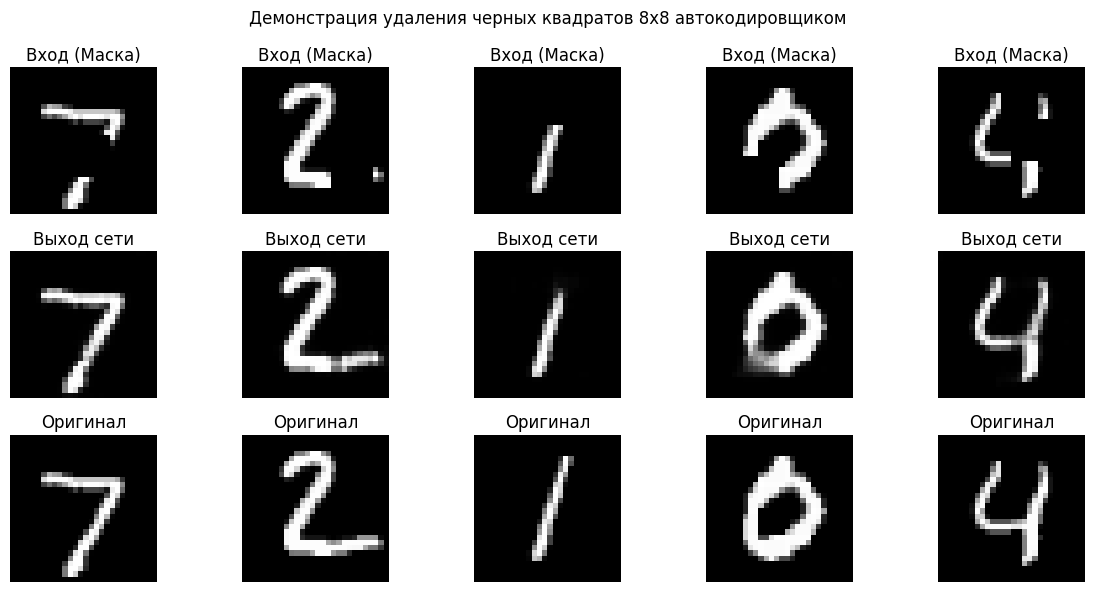

In [ ]:

# Пропускаем тестовые поврежденные изображения через сеть
decoded_imgs = autoencoder.predict(X_test_masked)

plt.figure(figsize=(12, 6))
num_images_to_show = 5
for i in range(num_images_to_show):
    # Поврежденное входное изображение (с квадратом)
    plt.subplot(3, num_images_to_show, i + 1)
    plt.imshow(X_test_masked[i].reshape(28, 28), cmap='gray')
    plt.title("Вход (Маска)")
    plt.axis('off')

    # Результат реставрации сетью
    plt.subplot(3, num_images_to_show, i + 1 + num_images_to_show)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Выход сети")
    plt.axis('off')

    # Истинный оригинал для сравнения
    plt.subplot(3, num_images_to_show, i + 1 + 2 * num_images_to_show)
    plt.imshow(X_test_org[i].reshape(28, 28), cmap='gray')
    plt.title("Оригинал")
    plt.axis('off')

plt.suptitle("Демонстрация удаления черных квадратов 8x8 автокодировщиком")
plt.tight_layout()
plt.show()